In [41]:
import numpy as np 
import pandas as pd 
import os, sys
from collections import defaultdict
from urllib.request import urlopen
import json
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import widgets
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import random
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.colors import n_colors
from plotly.subplots import make_subplots
init_notebook_mode(connected=True)
import cufflinks as cf
cf.go_offline()
from wordcloud import WordCloud , ImageColorGenerator
from PIL import Image
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve)

In [2]:
vote=pd.read_csv(r"C:\Users\vipul\Election data.csv")
vote.head()

,NAME,STATE,CONSTITUENCY,PARTY,GENDER,AGE,CATEGORY,EDUCATION,CRIMINAL,ASSETS,...,SYMBOL,GENERAL,POSTAL,TOTAL,% of Votes Secured - Over Total Votes Polled In Constituency,% of Votes Secured - Over Total Electors In Constituency,Over Total Valid Votes Polled In Constituency,Valid Votes,Total Votes Polled In The Constituency,TOTAL ELECTORS
0,KOTHAPALLI GEETHA,Andhra Pradesh,Araku,BJP,FEMALE,53,ST,Post Graduate,2,167166953.0,...,Lotus,417113,9312,426425,36.58,27.38,38.28,1113975,1165787,1557153
1,APPALANARASA PACHIPENTA,Andhra Pradesh,Araku,CPI(M),MALE,41,ST,Post Graduate,4,NaN,...,"Hammer, Sickle and Star",119016,4113,123129,10.56,7.91,11.05,1113975,1165787,1557153
2,KINJARAPU RAMMOHAN NAIDU,Andhra Pradesh,Srikakulam,TDP,MALE,36,GENERAL,Post Graduate,4,NaN,...,Bicycle,734501,19827,754328,60.78,45.81,62.29,1211081,1241169,1646686
3,PEDADA PARAMESWARA RAO,Andhra Pradesh,Srikakulam,INC,MALE,59,GENERAL,Doctorate,1,51575569.0,...,Hand,6724,448,7172,0.58,0.44,0.59,1211081,1241169,1646686
4,VABA YOGESWARA RAO,Andhra Pradesh,Srikakulam,IND,MALE,39,ST,10th Pass,3,NaN,...,Road roller,3472,126,3598,0.29,0.22,0.30,1211081,1241169,1646686


In [3]:
vote.columns

Index(['NAME', 'STATE', 'CONSTITUENCY', 'PARTY', 'GENDER', 'AGE', 'CATEGORY',
       'EDUCATION', 'CRIMINAL', 'ASSETS', 'LIABILITIES', 'WINNER', 'SYMBOL',
       'GENERAL', 'POSTAL', 'TOTAL',
       '% of Votes Secured - Over Total Votes Polled In Constituency',
       '% of Votes Secured - Over Total Electors In Constituency',
       'Over Total Valid Votes Polled In Constituency', 'Valid Votes',
       'Total Votes Polled In The Constituency', 'TOTAL ELECTORS'],
      dtype='object')

In [4]:
vote.dtypes

NAME                                                             object
STATE                                                            object
CONSTITUENCY                                                     object
PARTY                                                            object
GENDER                                                           object
AGE                                                               int64
CATEGORY                                                         object
EDUCATION                                                        object
CRIMINAL                                                          int64
ASSETS                                                          float64
LIABILITIES                                                     float64
WINNER                                                            int64
SYMBOL                                                           object
GENERAL                                                         

In [5]:
vote.shape

(1682, 22)

In [6]:
vote.describe()

,AGE,CRIMINAL,ASSETS,LIABILITIES,WINNER,GENERAL,POSTAL,TOTAL,% of Votes Secured - Over Total Votes Polled In Constituency,% of Votes Secured - Over Total Electors In Constituency,Over Total Valid Votes Polled In Constituency,Valid Votes,Total Votes Polled In The Constituency,TOTAL ELECTORS
count,1682.000000,1682.000000,1.126000e+03,1.126000e+03,1682.000000,1.682000e+03,1682.000000,1.682000e+03,1682.000000,1682.000000,1682.000000,1.682000e+03,1.682000e+03,1.682000e+03
mean,49.108205,3.474435,1.597356e+08,3.233140e+07,0.171225,1.724297e+05,1029.545779,1.734593e+05,14.362455,9.629923,14.520505,1.192213e+06,1.204077e+06,1.845357e+06
std,11.757472,9.721139,1.779649e+09,3.777711e+08,0.376817,2.461691e+05,2027.384135,2.476466e+05,19.852828,13.539279,20.070112,2.182533e+05,2.190580e+05,3.330648e+05
min,25.000000,1.000000,7.000000e+02,0.000000e+00,0.000000,1.100000e+02,0.000000,1.100000e+02,0.010000,0.000000,0.010000,4.906700e+04,4.924700e+04,5.795300e+04
25%,40.000000,1.000000,1.992300e+06,0.000000e+00,0.000000,1.670500e+03,4.000000,1.691500e+03,0.140000,0.092500,0.140000,1.060052e+06,1.074086e+06,1.661834e+06
50%,48.000000,1.500000,1.038007e+07,3.500000e+05,0.000000,6.778000e+03,28.000000,6.834000e+03,0.585000,0.390000,0.595000,1.176403e+06,1.189626e+06,1.825492e+06
75%,58.000000,3.000000,4.713992e+07,2.983870e+06,0.000000,3.878910e+05,1296.750000,3.898495e+05,34.202500,21.987500,34.512500,1.327791e+06,1.331386e+06,2.000402e+06
max,82.000000,243.000000,5.705473e+10,1.038000e+10,1.000000,1.111556e+06,19827.000000,1.116460e+06,76.660000,57.350000,77.780000,2.438593e+06,2.458780e+06,3.780453e+06


In [7]:
vote.isnull().sum()

NAME                                                              0
STATE                                                             0
CONSTITUENCY                                                      0
PARTY                                                             0
GENDER                                                            0
AGE                                                               0
CATEGORY                                                          0
EDUCATION                                                         0
CRIMINAL                                                          0
ASSETS                                                          556
LIABILITIES                                                     556
WINNER                                                            0
SYMBOL                                                            0
GENERAL                                                           0
POSTAL                                          

In [8]:
vote[vote.ASSETS.isnull()==True]['NAME'].unique()

array(['APPALANARASA PACHIPENTA', 'KINJARAPU RAMMOHAN NAIDU',
       'VABA YOGESWARA RAO', 'C.M.RAMESH',
       'TANGELLA UDAY SRINIVAS (TEA TIME UDAY)',
       'DAGGUBATI PURANDHESHWARI', 'UMABALA GUDURI', 'ADABALA SIVA',
       'PUTTA MAHESH KUMAR', 'GOLLU KRISHNA', 'JOGI VEERANJANEYULU',
       'KESINENI SRINIVAS (NANI)',
       'BARRE SREENIVASARAO (JAI BHEEM SRINIVAS)', 'DATLA LURTHU MERI',
       'JANGALA AJAY KUMAR', 'SHAIK. KHAJAVALI', 'ANIL KUMAR POLUBOINA',
       'SUBBARAO CHALLA', 'J.D. SEELAM', 'DR CHEVIREDDY BHASKAR REDDY',
       'NAGESWARA RAO', 'U P MUNI REDDY', 'B Y RAMAIAH',
       'DR.NALLANI RAMESH NAIDU', 'SREERANGARAJULA GOPINATH ROYAL',
       'KOPPALA RAGHU', 'AKBAR M BASHA', 'JOYANTA BASUMATARY',
       'FARUK KHAN', 'ABDUL KALAM MAZUMDER', 'PREMLAL GANJU',
       'RISHIRAJ KAUNDINYA', 'GAURAV GOGOI', 'DEEPAK YADAV',
       'RADHA MOHAN SINGH', 'DR RAJESH KUMAR', 'DEVESH CHANDRA THAKUR',
       'ASHOK KUMAR YADAV', 'PRIYE RANJAN', 'GANGA PRASAD YADAV',
       

In [9]:
vote.fillna('Not Available')

,NAME,STATE,CONSTITUENCY,PARTY,GENDER,AGE,CATEGORY,EDUCATION,CRIMINAL,ASSETS,...,SYMBOL,GENERAL,POSTAL,TOTAL,% of Votes Secured - Over Total Votes Polled In Constituency,% of Votes Secured - Over Total Electors In Constituency,Over Total Valid Votes Polled In Constituency,Valid Votes,Total Votes Polled In The Constituency,TOTAL ELECTORS
0,KOTHAPALLI GEETHA,Andhra Pradesh,Araku,BJP,FEMALE,53,ST,Post Graduate,2,167166953.0,...,Lotus,417113,9312,426425,36.58,27.38,38.28,1113975,1165787,1557153
1,APPALANARASA PACHIPENTA,Andhra Pradesh,Araku,CPI(M),MALE,41,ST,Post Graduate,4,Not Available,...,"Hammer, Sickle and Star",119016,4113,123129,10.56,7.91,11.05,1113975,1165787,1557153
2,KINJARAPU RAMMOHAN NAIDU,Andhra Pradesh,Srikakulam,TDP,MALE,36,GENERAL,Post Graduate,4,Not Available,...,Bicycle,734501,19827,754328,60.78,45.81,62.29,1211081,1241169,1646686
3,PEDADA PARAMESWARA RAO,Andhra Pradesh,Srikakulam,INC,MALE,59,GENERAL,Doctorate,1,51575569.0,...,Hand,6724,448,7172,0.58,0.44,0.59,1211081,1241169,1646686
4,VABA YOGESWARA RAO,Andhra Pradesh,Srikakulam,IND,MALE,39,ST,10th Pass,3,Not Available,...,Road roller,3472,126,3598,0.29,0.22,0.30,1211081,1241169,1646686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,RAJ KUMAR,Jammu and Kashmir,JAMMU,IND,MALE,49,SC,12th Pass,1,Not Available,...,Dolli,2611,7,2618,0.20,0.14,0.20,1297531,1309825,1818657
1678,RAJ KUMAR,Jammu and Kashmir,JAMMU,IND,MALE,49,SC,10th Pass,3,13004000.0,...,Dolli,2611,7,2618,0.20,0.14,0.20,1297531,1309825,1818657
1679,GANESH CHOUDHARY,Jammu and Kashmir,JAMMU,HSS,MALE,37,GENERAL,8th Pass,1,770000.0,...,Gas Stove,1187,3,1190,0.09,0.07,0.09,1297531,1309825,1818657
1680,VICKY KUMAR DOGRA,Jammu and Kashmir,JAMMU,IND,MALE,38,SC,10th Pass,3,260000.0,...,Bat,1163,2,1165,0.09,0.06,0.09,1297531,1309825,1818657


In [10]:
vote.rename(columns={"CRIMINAL":"CRIMINAL CASES", "GENERAL":"GENERAL VOTES","POSTAL":"POSTAL VOTES","TOTAL":"TOTAL VOTES",}, inplace=True)
vote.head()

,NAME,STATE,CONSTITUENCY,PARTY,GENDER,AGE,CATEGORY,EDUCATION,CRIMINAL CASES,ASSETS,...,SYMBOL,GENERAL VOTES,POSTAL VOTES,TOTAL VOTES,% of Votes Secured - Over Total Votes Polled In Constituency,% of Votes Secured - Over Total Electors In Constituency,Over Total Valid Votes Polled In Constituency,Valid Votes,Total Votes Polled In The Constituency,TOTAL ELECTORS
0,KOTHAPALLI GEETHA,Andhra Pradesh,Araku,BJP,FEMALE,53,ST,Post Graduate,2,167166953.0,...,Lotus,417113,9312,426425,36.58,27.38,38.28,1113975,1165787,1557153
1,APPALANARASA PACHIPENTA,Andhra Pradesh,Araku,CPI(M),MALE,41,ST,Post Graduate,4,NaN,...,"Hammer, Sickle and Star",119016,4113,123129,10.56,7.91,11.05,1113975,1165787,1557153
2,KINJARAPU RAMMOHAN NAIDU,Andhra Pradesh,Srikakulam,TDP,MALE,36,GENERAL,Post Graduate,4,NaN,...,Bicycle,734501,19827,754328,60.78,45.81,62.29,1211081,1241169,1646686
3,PEDADA PARAMESWARA RAO,Andhra Pradesh,Srikakulam,INC,MALE,59,GENERAL,Doctorate,1,51575569.0,...,Hand,6724,448,7172,0.58,0.44,0.59,1211081,1241169,1646686
4,VABA YOGESWARA RAO,Andhra Pradesh,Srikakulam,IND,MALE,39,ST,10th Pass,3,NaN,...,Road roller,3472,126,3598,0.29,0.22,0.30,1211081,1241169,1646686


In [11]:
vote.EDUCATION.unique()

array(['Post Graduate', 'Doctorate', '10th Pass', 'Graduate Professional',
       '12th Pass', '5th Pass', 'Graduate', 'Others', '8th Pass',
       'Illiterate', 'Literate', 'Not Given'], dtype=object)

In [12]:
vote.dtypes

NAME                                                             object
STATE                                                            object
CONSTITUENCY                                                     object
PARTY                                                            object
GENDER                                                           object
AGE                                                               int64
CATEGORY                                                         object
EDUCATION                                                        object
CRIMINAL CASES                                                    int64
ASSETS                                                          float64
LIABILITIES                                                     float64
WINNER                                                            int64
SYMBOL                                                           object
GENERAL VOTES                                                   

In [13]:
vote['ASSETS']=pd.to_numeric(vote['ASSETS'])
vote['LIABILITIES']=pd.to_numeric(vote['LIABILITIES'])
vote['CRIMINAL CASES'].replace({np.NaN:0})
vote['CRIMINAL CASES'] = pd.to_numeric(vote['CRIMINAL CASES'], errors='coerce').fillna(0).astype(np.int64)

# The Analysis

# State and Constituency Level Analysis

# What is the distribution of Constituencies over all the states?

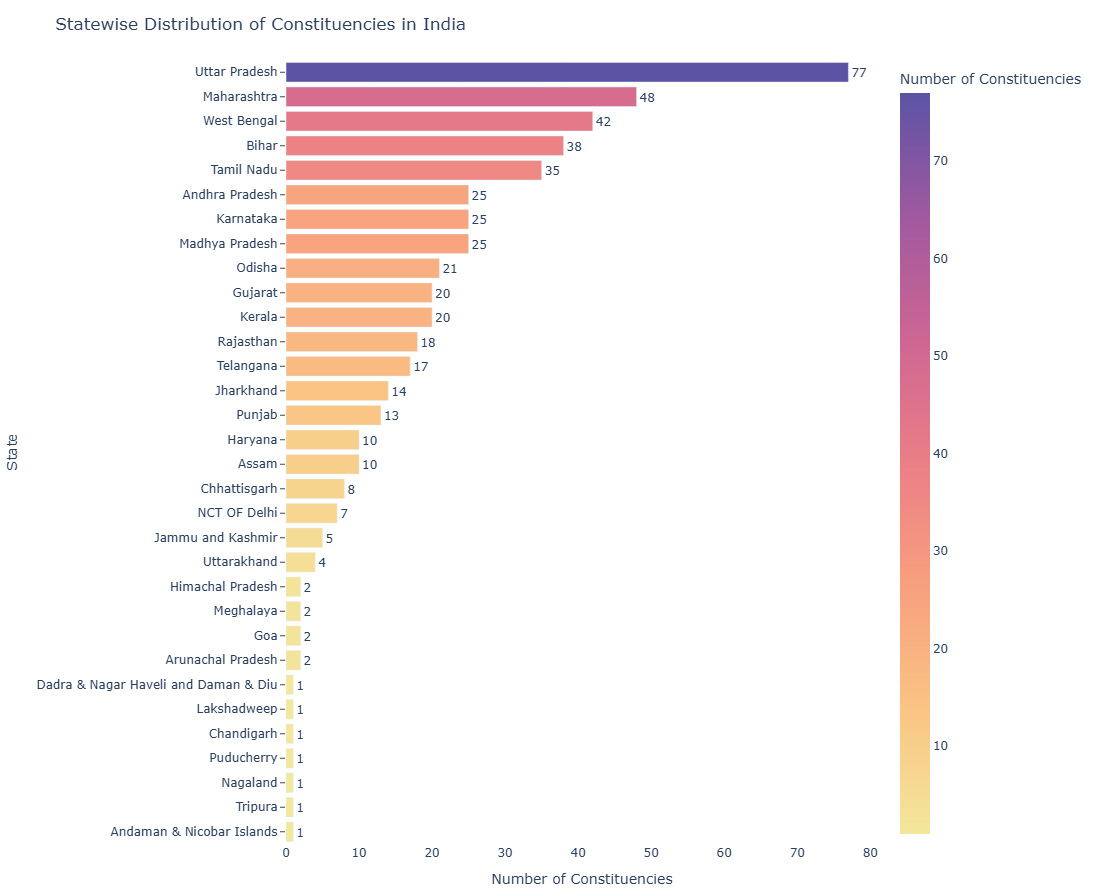

In [14]:
st_con = vote.groupby('STATE')['CONSTITUENCY'].nunique().reset_index()
st_con.columns = ['STATE', '# Constituency']
st_con['STATE'] = st_con['STATE'].str.strip()
st_con = st_con.sort_values('# Constituency', ascending=True)
fig = px.bar(
    st_con,
    y='STATE', x='# Constituency',
    orientation='h',
    color='# Constituency',
    color_continuous_scale='Sunset',
    title='Statewise Distribution of Constituencies in India',
    labels={'STATE': 'State', '# Constituency': 'Number of Constituencies'}
)

fig.update_layout(
    height=28 * len(st_con), 
    margin=dict(l=200, r=50, t=60, b=40),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_yaxes(automargin=True, ticks='outside')
fig.update_traces(text=st_con['# Constituency'], textposition='outside')

fig.show()


# Lets create a Sunburst image of all the States and Constituencies

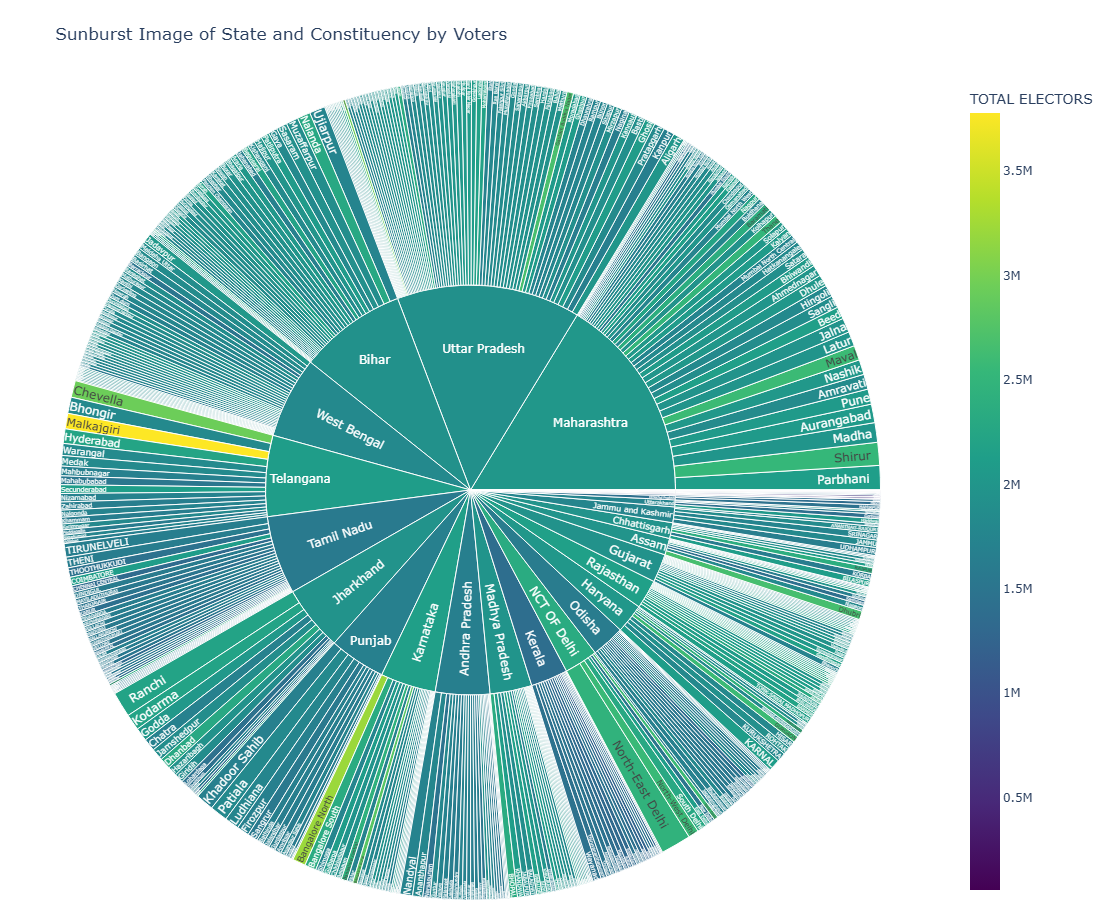

In [15]:
st_con_vt=vote[['STATE','CONSTITUENCY','TOTAL ELECTORS']]
fig = px.sunburst(st_con_vt, path=['STATE','CONSTITUENCY'], values='TOTAL ELECTORS',
                  color='TOTAL ELECTORS',
                  color_continuous_scale='Viridis')
fig.update_layout(title_text='Sunburst Image of State and Constituency by Voters',template='plotly_white',width=900, height=900,margin=dict(t=80, l=0, r=0, b=0))
fig.show()


# Party Level Analysis

# Which Parties have been present in most constituencies and States?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\530942749.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\530942749.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



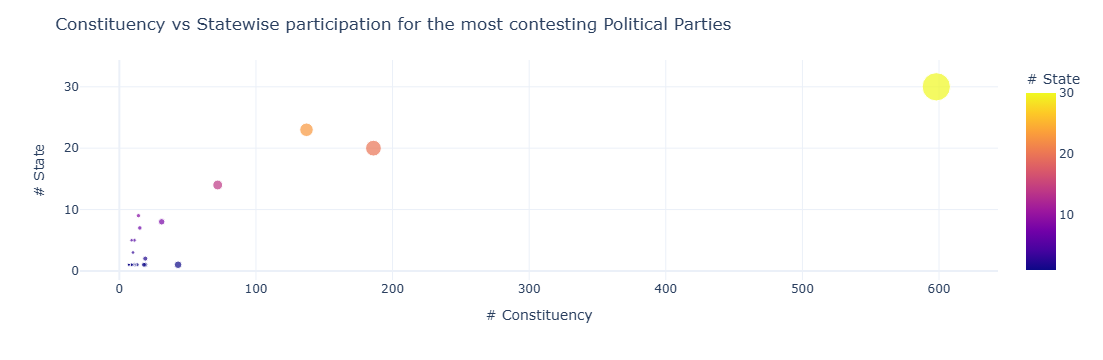

In [16]:
vote_prty=vote[vote['PARTY']!='NOTA']
prty_cnt=vote_prty.groupby('PARTY').apply(lambda x:x['CONSTITUENCY'].count()).reset_index(name='# Constituency')
prty_st=vote_prty.groupby('PARTY').apply(lambda x:x['STATE'].nunique()).reset_index(name='# State')
prty_cnt.sort_values(by='# Constituency',ascending=False,inplace=True)
prty_top_cn=prty_cnt[:25]
prty_top_all=pd.merge(prty_top_cn,prty_st,how='inner',left_on='PARTY',right_on='PARTY')
fig = px.scatter(prty_top_all, x='# Constituency', y='# State', color='# State',
                 size='# Constituency', hover_data=['PARTY'])
fig.update_layout(title_text='Constituency vs Statewise participation for the most contesting Political Parties',template='plotly_white')
fig.show()

# What has been the performance of the Parties Statewise?

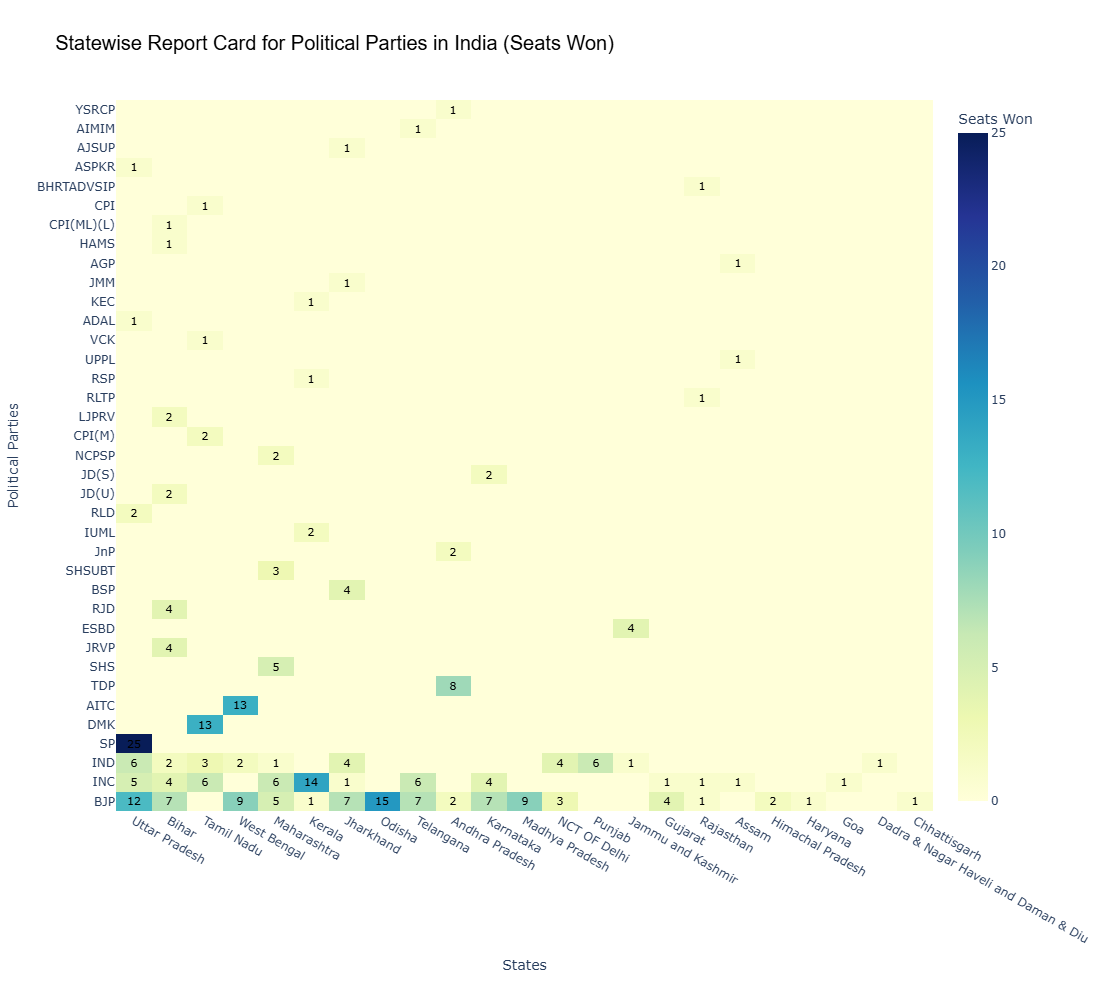

In [19]:
st_prty = vote_prty.groupby(['PARTY','STATE'])['WINNER'].sum().reset_index(name='Seats Won')
pvt = st_prty.pivot(index='PARTY', columns='STATE', values='Seats Won').fillna(0).astype(int)
pvt = pvt.loc[pvt.sum(1)>0, pvt.sum()>0]
pvt = pvt.loc[pvt.sum(1).sort_values(ascending=False).index,
              pvt.sum().sort_values(ascending=False).index]
text_values = pvt.astype(str).replace('0', '')

fig = go.Figure(data=go.Heatmap(
    z=pvt.values,
    x=pvt.columns,
    y=pvt.index,
    text=text_values,                  
    texttemplate="%{text}",
    textfont={"size":11, "color":"black"},
    colorscale='YlGnBu',
    colorbar_title='Seats Won'
))
fig.update_layout(
    title='Statewise Report Card for Political Parties in India (Seats Won)',
    title_font=dict(size=20, family='Arial', color='black'),
    xaxis_title='States',
    yaxis_title='Political Parties',
    width=1100,
    height=0.45 * len(pvt) * 35 + 400,  
    template='plotly_white'
)

fig.show()


# Which party has won the most constituencies?¶

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\748873827.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



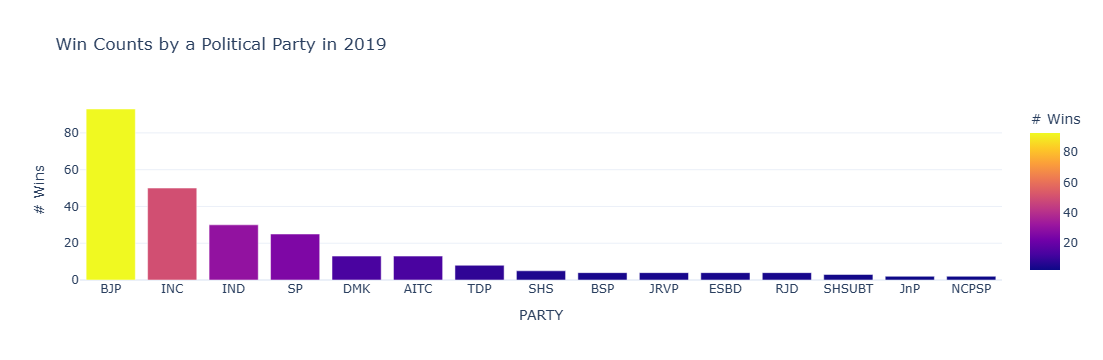

In [20]:
part_win=vote.groupby('PARTY').apply(lambda x:x['WINNER'].sum()).reset_index(name='# Wins')
part_win.sort_values(by='# Wins',ascending=False,inplace=True)
top_part_win=part_win[0:15]
fig = px.bar(top_part_win, x='PARTY', y='# Wins',
                     color='# Wins',title='Win Counts by a Political Party in 2019')
fig.update_layout(title_text='Win Counts by a Political Party in 2019',template='plotly_white')
fig.show()

# What has been the general Win vs Loss relationship for the Parties in 2024?

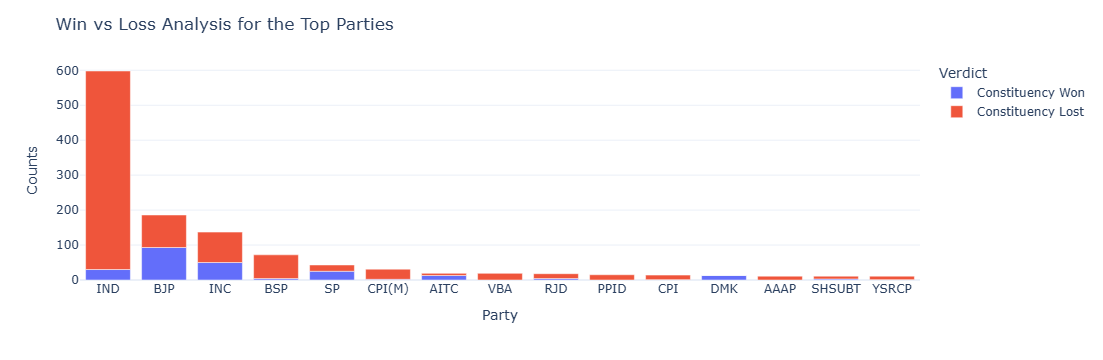

In [21]:

prty_cnt_win=pd.merge(prty_cnt,part_win,how='inner',left_on='PARTY',right_on='PARTY')
prty_cnt_win['Lost']=prty_cnt_win['# Constituency']-prty_cnt_win['# Wins']
prty_wins_cnt=prty_cnt_win[['PARTY','# Wins']]
prty_wins_cnt['Verdict']='Constituency Won'
prty_loss_cnt=prty_cnt_win[['PARTY','Lost']]
prty_loss_cnt['Verdict']='Constituency Lost'
prty_wins_cnt.columns=['Party','Counts','Verdict']
prty_loss_cnt.columns=['Party','Counts','Verdict']
top_prty_wins_cnt=prty_wins_cnt[:15]
prty_loss_cnt_cnt=prty_loss_cnt[:15]
prt_win_loss=pd.concat([top_prty_wins_cnt,prty_loss_cnt_cnt])
fig = px.bar(prt_win_loss, x='Party', y='Counts', color='Verdict')
fig.update_layout(title_text='Win vs Loss Analysis for the Top Parties',template='plotly_white')
fig.show()

# Politician Level Analytics

# What is the Gender Ratio of the Contestants? Also the Gender Ratio of the Winners?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\2450087703.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\2450087703.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



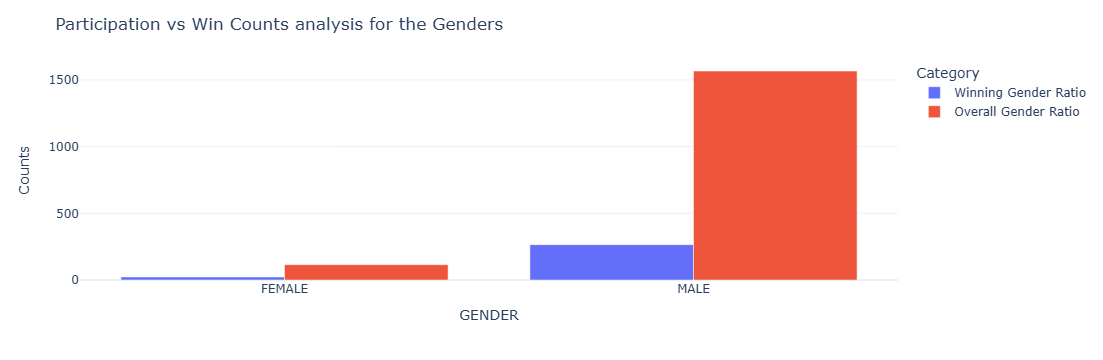

In [23]:
vote_gndr=vote[vote['PARTY']!='NOTA']
gndr_overall=vote_gndr.groupby('GENDER').apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
gndr_overall['Category']='Overall Gender Ratio'
winners=vote_gndr[vote_gndr['WINNER']==1]
gndr_winner=winners.groupby('GENDER').apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
gndr_winner['Category']='Winning Gender Ratio'
gndr_overl_win=pd.concat([gndr_winner,gndr_overall])
fig = px.bar(gndr_overl_win, x='GENDER', y='Counts',
             color='Category', barmode='group')
fig.update_layout(title_text='Participation vs Win Counts analysis for the Genders',template='plotly_white')
fig.show()

# What is the Educational Qualification of our politicians?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\3641917151.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



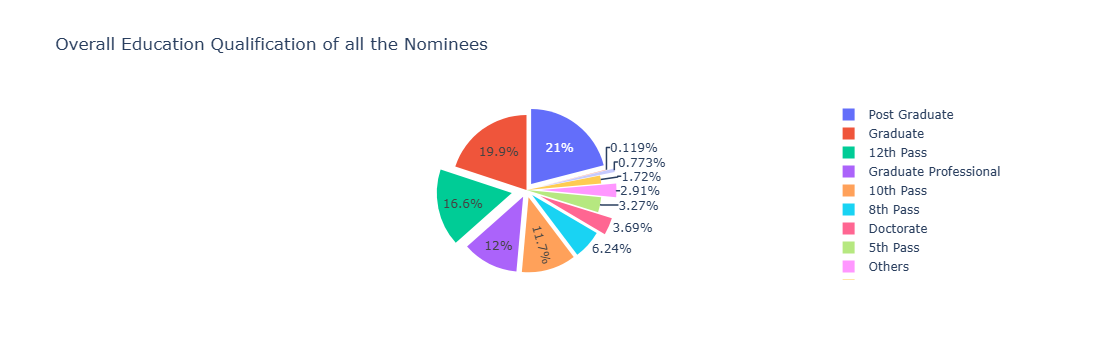

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\3641917151.py:7: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



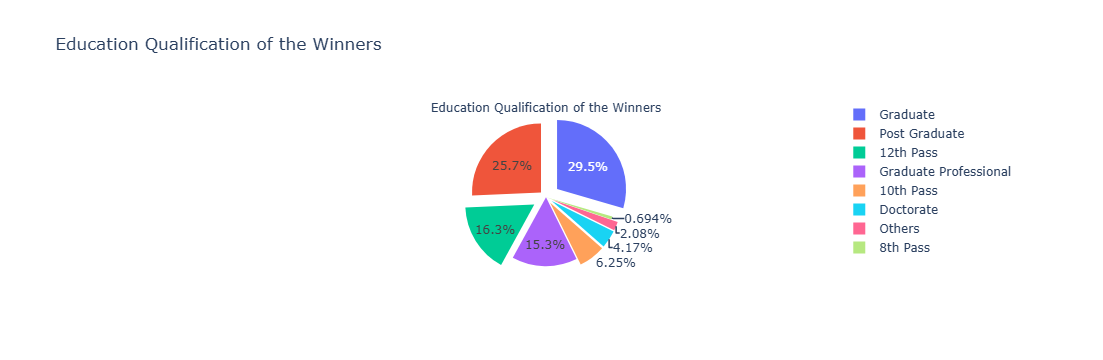

In [24]:
ed_valid=vote[vote['PARTY']!="NOTA"]
ed_cnt=ed_valid.groupby('EDUCATION').apply(lambda x:x['PARTY'].count()).reset_index(name='Counts')
fig = go.Figure(data=[go.Pie(labels=ed_cnt['EDUCATION'], values=ed_cnt['Counts'], pull=[0.1, 0.2, 0, 0.1, 0.2, 0,0.1, 0.2, 0,0.1, 0.2, 0.1])])
fig.update_layout(title_text='Overall Education Qualification of all the Nominees',template='plotly_white')
fig.show()
ed_won=ed_valid[ed_valid['WINNER']==1]
ed_win_cnt=ed_won.groupby('EDUCATION').apply(lambda x:x['PARTY'].count()).reset_index(name='Counts')
fig2 = go.Figure(data=[go.Pie(labels=ed_win_cnt['EDUCATION'], values=ed_win_cnt['Counts'], pull=[0.1, 0.2, 0, 0.1, 0.2, 0,0.1, 0.1, 0.2,0, 0.1, 0.2],title='Education Qualification of the Winners')])
fig2.update_layout(title_text='Education Qualification of the Winners',template='plotly_white')
fig2.show()

# What is the relationship of Age and Politics?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\1022221663.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



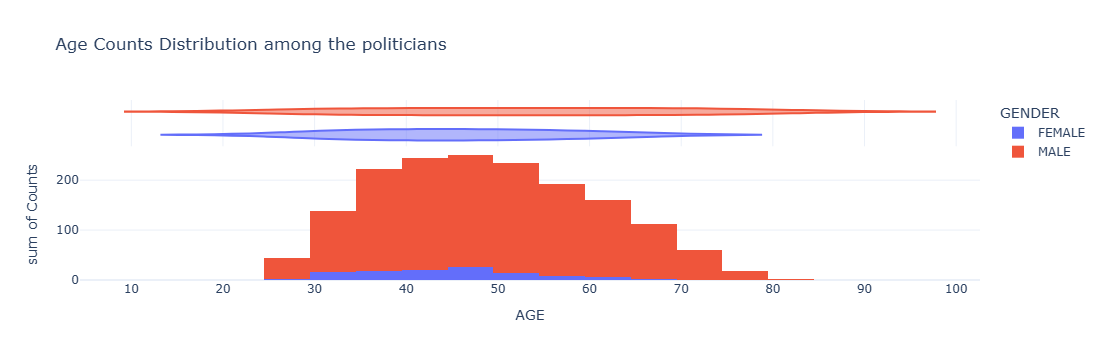

In [25]:
age_cnt=ed_valid.groupby(['AGE','GENDER']).apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
fig = px.histogram(age_cnt, x="AGE",y='Counts',color='GENDER',marginal='violin',title='Age Counts Distribution among the politicians')
fig.update_layout(title_text='Age Counts Distribution among the politicians',template='plotly_white')
fig.show()

# What relation does the Politician category have with the election results?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\844798426.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\844798426.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



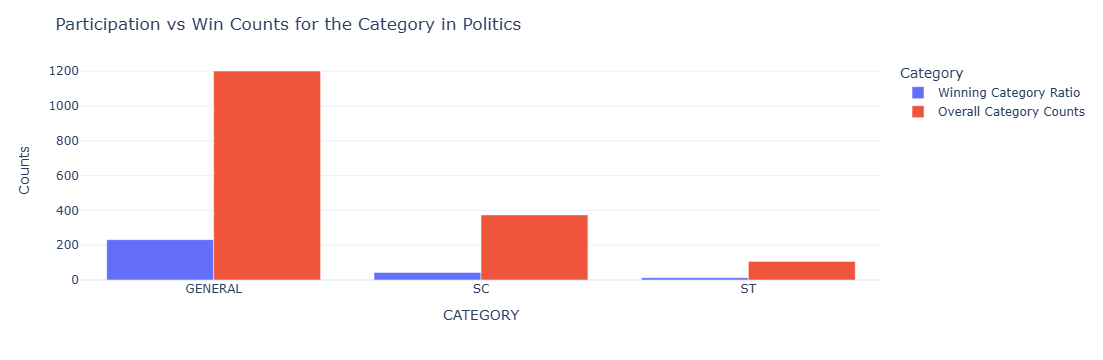

In [26]:
vote_cat=vote[vote['PARTY']!='NOTA']
cat_overall=vote_cat.groupby('CATEGORY').apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
cat_overall['Category']='Overall Category Counts'
winners_cat=vote_gndr[vote_gndr['WINNER']==1]
cat_winner=winners_cat.groupby('CATEGORY').apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
cat_winner['Category']='Winning Category Ratio'
cat_overl_win=pd.concat([cat_winner,cat_overall])
fig = px.bar(cat_overl_win, x='CATEGORY', y='Counts',
             color='Category', barmode='group')
fig.update_layout(title_text='Participation vs Win Counts for the Category in Politics',template='plotly_white')
fig.show()


# Have the politicians been involved with criminal activities?

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\1483048570.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



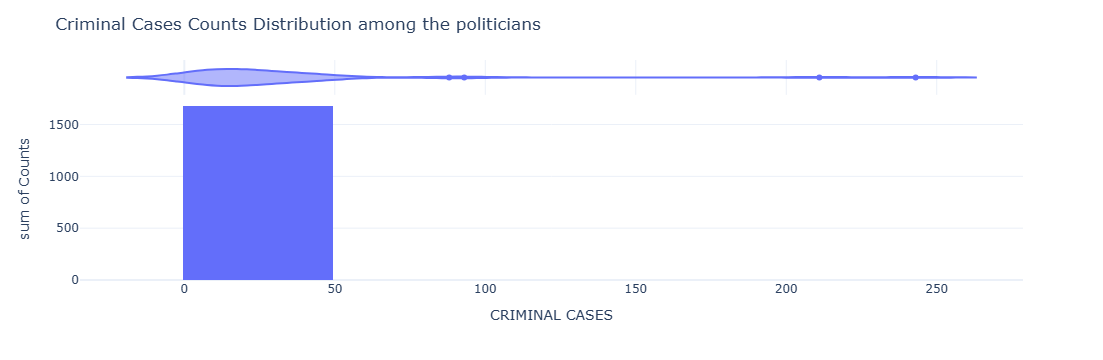

In [27]:
crim_cnt=ed_valid.groupby('CRIMINAL CASES').apply(lambda x:x['NAME'].count()).reset_index(name='Counts')
fig = px.histogram(crim_cnt, x='CRIMINAL CASES',y='Counts',marginal='violin')
fig.update_layout(title_text='Criminal Cases Counts Distribution among the politicians',template='plotly_white')
fig.show()

 # Plotting the Assets vs Liabilities amount for Winning Politicians (Plotted w.r.t State)

C:\Users\vipul\AppData\Local\Temp\ipykernel_14932\1390022094.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





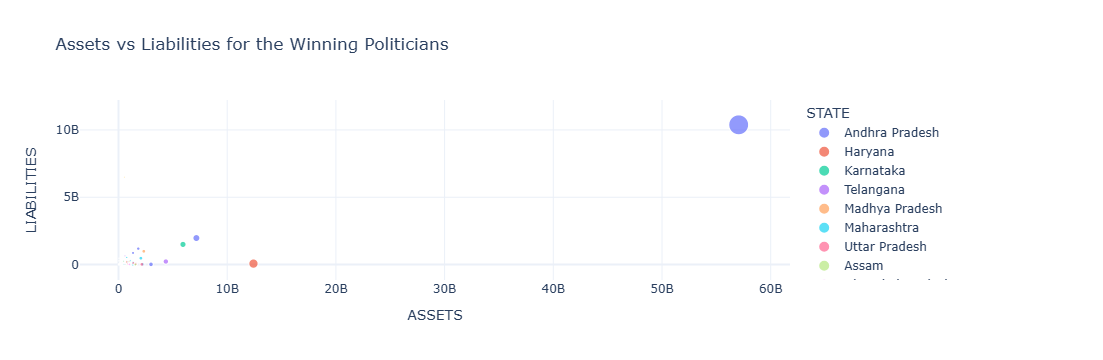

In [28]:
as_liab_name = ed_valid[['NAME', 'PARTY', 'ASSETS', 'LIABILITIES', 'STATE', 'CONSTITUENCY', 'WINNER']]
as_liab_name.WINNER.replace({1: 'Yes', 0: 'No'}, inplace=True)
as_liab_name['ASSETS'] = as_liab_name['ASSETS'].fillna(0)
as_liab_name.sort_values(by='ASSETS', ascending=False, inplace=True)
fig = px.scatter(as_liab_name, x='ASSETS', y='LIABILITIES', 
                 color='STATE', size='ASSETS', 
                 hover_data=(['NAME', 'PARTY', 'CONSTITUENCY', 'STATE', 'WINNER']),
                 title='Assets vs Liabilities for the Winning Politicians')

fig.update_layout(title_text='Assets vs Liabilities for the Winning Politicians', template='plotly_white')
fig.show()

# Prediction

# Random forest

In [37]:
vote_df = vote[vote['PARTY']!='NOTA'].copy()
vote_df['GENDER']   = vote_df['GENDER'].map({'MALE':1,'FEMALE':2})
vote_df['CATEGORY'] = vote_df['CATEGORY'].map({'GENERAL':1,'SC':2,'ST':3})
vote_df['PARTY']    = vote_df['PARTY'].map({p:i+1 for i,p in enumerate(vote_df['PARTY'].unique())})
vote_df['EDUCATION']= vote_df['EDUCATION'].map({e:i+1 for i,e in enumerate(vote_df['EDUCATION'].unique())})

df = vote_df[['STATE','CONSTITUENCY','WINNER','PARTY','SYMBOL','GENDER',
              'CRIMINAL CASES','AGE','CATEGORY','EDUCATION',
              'TOTAL VOTES','TOTAL ELECTORS','ASSETS','LIABILITIES']]

dataset = pd.get_dummies(df, drop_first=False)
num_cols = ['PARTY','EDUCATION','CRIMINAL CASES','AGE','TOTAL VOTES',
            'TOTAL ELECTORS','ASSETS','CATEGORY','LIABILITIES','GENDER']

scaler = StandardScaler()
dataset[num_cols] = scaler.fit_transform(dataset[num_cols])

In [38]:
df_not = dataset[dataset.WINNER==0]
df_win = dataset[dataset.WINNER==1]
df_win_up = resample(df_win, replace=True, n_samples=len(df_not), random_state=0)
data_bal = pd.concat([df_not, df_win_up], ignore_index=True)

X = data_bal.drop('WINNER', axis=1)
y = data_bal['WINNER']

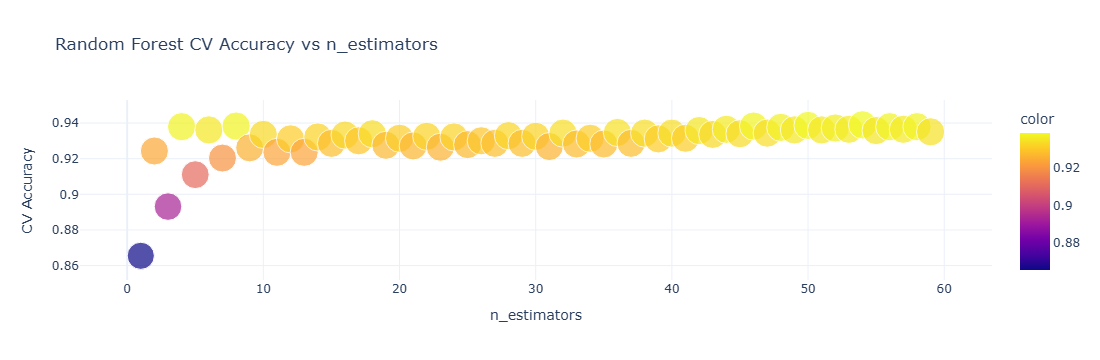

In [39]:
rf_scores = []
for k in range(1, 60):
    rf = RandomForestClassifier(n_estimators=k, random_state=0, n_jobs=-1)
    rf_scores.append(cross_val_score(rf, X, y, cv=10).mean())

fig = px.scatter(x=list(range(1,60)), y=rf_scores, color=rf_scores, size=rf_scores,
                 labels={'x':'n_estimators','y':'CV Accuracy'},
                 title='Random Forest CV Accuracy vs n_estimators',
                 template='plotly_white')
fig.show()

Evaluation (test set)
Accuracy  : 0.9469
Precision : 0.9147
Recall    : 0.9856
F1-score  : 0.9488
ROC-AUC   : 0.9969

Confusion Matrix:
 [[317  32]
 [  5 343]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9845    0.9083    0.9449       349
           1     0.9147    0.9856    0.9488       348

    accuracy                         0.9469       697
   macro avg     0.9496    0.9470    0.9468       697
weighted avg     0.9496    0.9469    0.9468       697



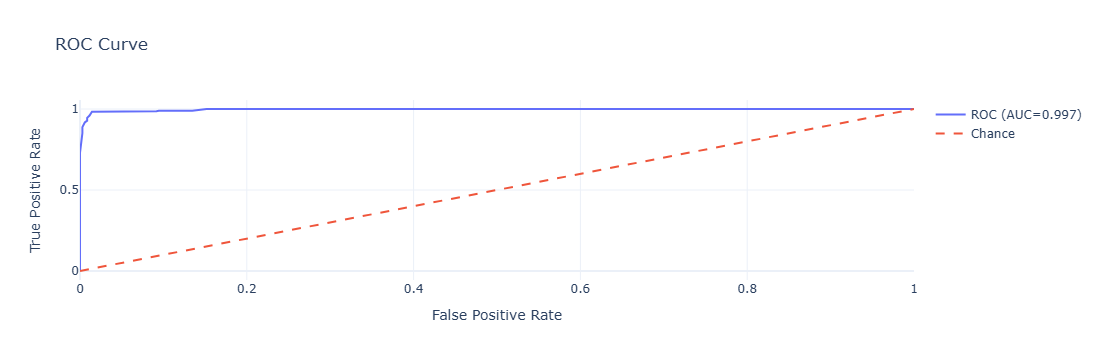

In [42]:
rf = RandomForestClassifier(n_estimators=38, random_state=0, n_jobs=-1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:,1]

acc  = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec  = recall_score(y_te, y_pred)
f1   = f1_score(y_te, y_pred)
auc  = roc_auc_score(y_te, y_prob)
cm   = confusion_matrix(y_te, y_pred)

print("Evaluation (test set)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_te, y_pred, digits=4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC={auc:.3f})'))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Chance', line=dict(dash='dash')))
fig_roc.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate',
                      template='plotly_white')
fig_roc.show()

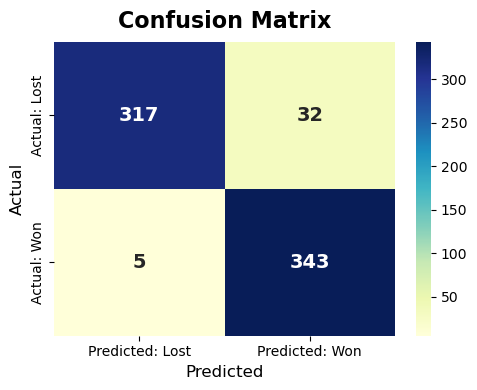

In [43]:
cm = confusion_matrix(y_te, y_pred)
# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Predicted: Lost', 'Predicted: Won'],
            yticklabels=['Actual: Lost', 'Actual: Won'],
            annot_kws={'size':14, 'weight':'bold'})

plt.title('Confusion Matrix', fontsize=16, weight='bold', pad=10)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


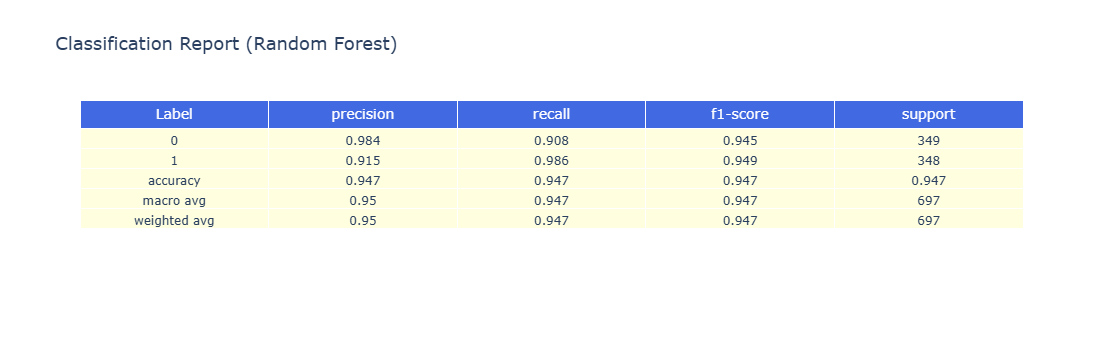

In [45]:
report = classification_report(y_te, y_pred, output_dict=True)
df = pd.DataFrame(report).T.round(3).reset_index()
df.rename(columns={'index': 'Label'}, inplace=True)

fig = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='royalblue',
                font=dict(color='white', size=14),
                align='center'),
    cells=dict(values=[df[col] for col in df.columns],
               fill_color='lightyellow',
               align='center',
               font=dict(size=12))
)])
fig.update_layout(title='Classification Report (Random Forest)', title_font_size=18)
fig.show()